# **Fangraphs 데이터를 사용한 회귀 모델 실습**

데이터 소스: 팬그래프 MLB 통계 <br>
https://www.fangraphs.com/leaders/major-league?pos=all&stats=pit&type=8

# 라이브러리 설치

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')

# 데이터 불러오기

In [2]:
df = pd.read_csv("Fangraphs.csv", encoding='cp949')
df

,Name,Win,Loss,Game,IP,K/9,BB/9,HR/9,ERA,FIP,WAR
0,Zack Wheeler,65,35,146,908.0,10.32,2.02,0.87,2.90,2.95,26.7
1,Logan Webb,64,46,158,963.0,8.44,1.98,0.61,3.21,2.92,22.9
2,Kevin Gausman,62,47,157,922.0,9.91,2.31,0.93,3.32,3.12,22.6
3,Dylan Cease,56,47,161,879.0,11.24,3.68,0.96,3.73,3.38,20.3
4,Corbin Burnes,51,32,136,821.1,10.09,2.47,0.89,2.91,3.15,20.1
...,...,...,...,...,...,...,...,...,...,...,...
200,Zach Davies,10,22,77,364.2,7.11,4.10,1.38,5.43,5.02,1.2
201,Josiah Gray,17,27,74,386.2,8.89,4.28,1.89,4.84,5.51,0.8
202,Jos? Ure?a,12,32,108,404.1,5.83,3.76,1.29,4.99,5.08,0.5
203,Chad Kuhl,11,24,102,309.0,7.86,4.46,1.49,5.71,5.26,0.0


# ERA 예측

가중치 = [ 1.36519353  0.36072037 -0.22259684]
편향  = 3.259999817417701

MSE 손실 = 0.15257614955015253


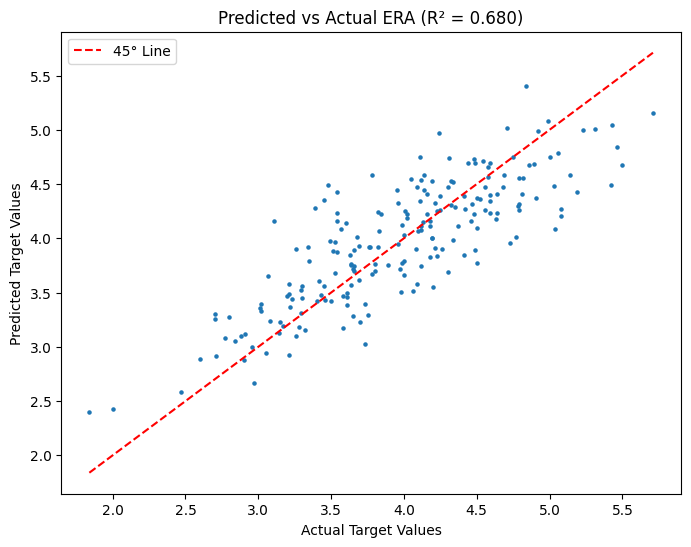

이 투수의 ERA는 [3.87292954]로 예측됩니다.


In [3]:
y1=df['ERA']
X = df[['HR/9', 'BB/9', 'K/9']]

MLB1 = LinearRegression()
MLB1.fit(X, y1)

print("가중치 =", MLB1.coef_)
print("편향  =", MLB1.intercept_); print()

y_pred1 = MLB1.predict(X) # 피쳐 X를 사용하여 모형의 예측값 계산
MSE = mean_squared_error(y1, y_pred1)
print("MSE 손실 =", MSE)

from sklearn.metrics import mean_squared_error, r2_score
acc1 = r2_score(y1, y_pred1)  # R²예측력 계산

# 예측값과 실제값 비교 그림 (45도 기준선 방법)
plt.figure(figsize=(8, 6))
plt.scatter(y1, y_pred1, s=5)  # s는 점의 크기 조절
plt.plot([y1.min(), y1.max()], [y1.min(), y1.max()], color='red', linestyle='--', label='45° Line')
plt.title(f'Predicted vs Actual ERA (R² = {acc1:.3f})')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.legend(); plt.show()

X_new = [[1, 1, 5]]
print(f"이 투수의 ERA는 {MLB1.predict(X_new)}로 예측됩니다.")

# FIP 예측

가중치 = [ 1.42707414  0.35491092 -0.21941277]
편향  = 3.2300736265576626

MSE 손실 = 0.003819931248107583


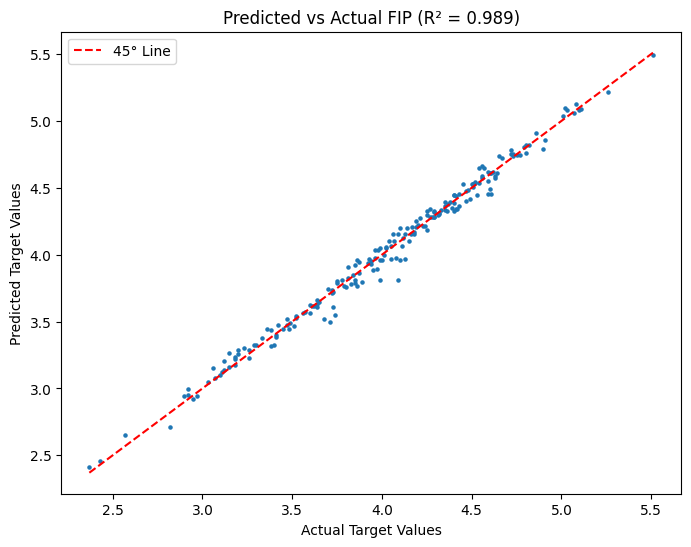

이 투수의 FIP은 [3.91499482]로 예측됩니다.


In [4]:
y2=df['FIP']
X = df[['HR/9', 'BB/9', 'K/9']]

MLB2 = LinearRegression()
MLB2.fit(X, y2)

print("가중치 =", MLB2.coef_)
print("편향  =", MLB2.intercept_); print()

y_pred2 = MLB2.predict(X)
MSE = mean_squared_error(y2, y_pred2)
print("MSE 손실 =", MSE)

from sklearn.metrics import mean_squared_error, r2_score
acc2 = r2_score(y2, y_pred2)

# 예측값과 실제값 비교 그림
plt.figure(figsize=(8, 6))
plt.scatter(y2, y_pred2, s=5)
plt.plot([y2.min(), y2.max()], [y2.min(), y2.max()], color='red', linestyle='--', label='45° Line')
plt.title(f'Predicted vs Actual FIP (R² = {acc2:.3f})')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.legend(); plt.show()

X_new = [[1, 1, 5]]
print(f"이 투수의 FIP은 {MLB2.predict(X_new)}로 예측됩니다.")

### ERA는 모델의 피처인 (홈런, 볼넷, 삼진 수)외에 여러가지 다른 특성에 따라 달라지지만 FIP은 실제로 (홈런, 볼넷, 삼진 수)로만 계산되기 때문이다.  

그림 합치기

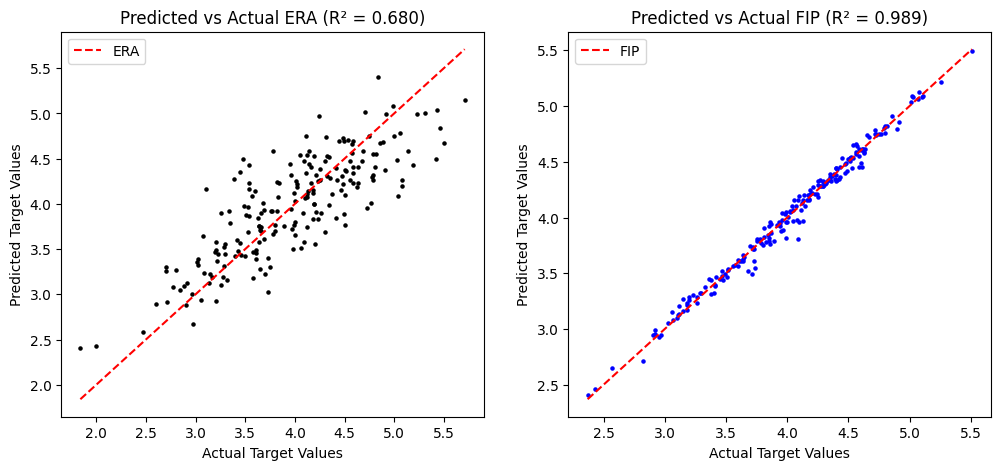

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)  # 그림 위치 1
plt.scatter(y1, y_pred1, color="k", s=5)
plt.plot([y1.min(), y1.max()], [y1.min(), y1.max()], color='red', linestyle='--', label='ERA')
plt.title(f'Predicted vs Actual ERA (R² = {acc1:.3f})')
plt.xlabel('Actual Target Values'); plt.ylabel('Predicted Target Values')
plt.legend()

plt.subplot(1,2,2)  # 그림 위치 2
plt.scatter(y2, y_pred2, color="b", s=5)
plt.plot([y2.min(), y2.max()], [y2.min(), y2.max()], color='red', linestyle='--', label='FIP')
plt.title(f'Predicted vs Actual FIP (R² = {acc2:.3f})')
plt.xlabel('Actual Target Values'); plt.ylabel('Predicted Target Values')
plt.legend()
plt.show()
